# Unbinned image deconvolution -- minimal example

The shortest path through `UnbinnedImageDataInterface`: set the parameters, build
the interface, run Richardson-Lucy, plot the final model.  Six 511 keV source
simulations, no background component.

`Unbinned-ImageDeconvolution.ipynb` covers what is left out here -- what the
normalization bin is for, background-normalization fitting, response-matrix
caching, and how the sparse sampling below affects the flux scale.


In [13]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
from mhealpy import HealpixMap

from cosipy.util import fetch_wasabi_file
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.interfaces.event_selection import EventSelectorInterface
from cosipy.data_io.EmCDSUnbinnedData import (
    TimeTagEmCDSEventDataInSCFrameFromArrays,
    TimeTagEmCDSEventDataInSCFrameFromDC3Fits,
)
from cosipy.response.ml.NFResponse import NFResponse
from cosipy.response.ml.nf_instrument_response_function import (
    UnpolarizedNFFarFieldInstrumentResponseFunction,
)
from cosipy.interfaces.unbinned_image_data_interface import UnbinnedImageDataInterface
from cosipy.image_deconvolution.image_deconvolution import ImageDeconvolution
from cosipy.image_deconvolution.data_interfaces.data_interface_collection import (
    DataInterfaceCollection,
)


class EnergySelector(EventSelectorInterface):
    """Keep events in [emin, emax] keV.  cosipy ships no energy selector."""

    def __init__(self, emin_keV, emax_keV):
        self._emin = emin_keV
        self._emax = emax_keV

    def _select(self, events, early_stop=True):
        energy = np.asarray(events.energy_keV, dtype=float)
        return (energy >= self._emin) & (energy <= self._emax)


%matplotlib inline


In [14]:
DATA_DIR = Path(".")

# --- Inputs, as Wasabi bucket keys -----------------------------------------
# All DC4.  These are the DC4 positron sky: the two 511 keV line components and
# the two continua that come with them.  Add or remove entries freely -- they are
# merged into one event list below.  DC4 has no standalone bulge, 26Al, or 44Ti
# positron file; those exist only under DC3, whose events share this same 92-day
# timeline if you want to mix them back in with a full "COSI-SMEX/DC3/..." key.
SOURCE_PREFIX = "COSI-SMEX/DC4/Data/Sources/"
SOURCE_KEYS = [SOURCE_PREFIX + _name for _name in [
    # Line sources -- about half of each file lands in the 505-517 keV band.
    "Positrons_Central_Source_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "positrons_thin_disk_line_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    # Continua, ~1.5% each in band: ortho-positronium and in-flight annihilation.
    "positrons_thin_disk_cont_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    "positron_annihilation_in_flight_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
    # The DC4 halo, and the nearest thing to the DC3 bulge this replaces -- but an
    # NFW profile, not a bulge, and a dark-matter spectrum rather than a line
    # (only 1.2% in band).  Left out by default: 282 MB for ~52k usable events.
    # "Annihilation_eeg_NFW_3months_unbinned_data_filtered_with_SAAcut.fits.gz",
]]
SC_KEY = "COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits"
RSP_KEY = "COSI-SMEX/DC4/Data/Responses/unpolarized_nfresponse_v1-01.pt"

# --- Model ------------------------------------------------------------------
# The model has a single incident-energy bin and the IRF is evaluated at its
# midpoint, so the band must stay narrow around the line.
E_MIN_KEV, E_MAX_KEV = 505.0, 517.0
ENERGY_EDGES = [E_MIN_KEV, E_MAX_KEV]
NSIDE = 4                      # 4 -> 192 pixels, 8 -> 768, 16 -> 3072

# --- Cost -------------------------------------------------------------------
# The response matrix is dense (npix, n_events) float64 and is built with one IRF
# evaluation per pixel over the event list, so both memory and runtime are linear
# in N_EVENTS.  None keeps every event in the band (~86k -> 0.5 GB at nside 8).
N_EVENTS = 4000
SEED = 12345
DEVICES = ["cpu"]              # ["cuda"] if you have a GPU

# --- Plot -------------------------------------------------------------------
VMIN, VMAX = None, None        # None -> peak / 1e3 and peak

PARFILE = DATA_DIR / "imagedeconvolution_parfile_minimal.yml"
PARFILE.write_text("""model_definition:
  class: "AllSkyImage"
  property:
    nside: 4
    energy_edges:
      value: [505.0, 517.0]
      unit: "keV"
    scheme: "ring"
    coordinate: "galactic"
    unit: "cm-2 s-1 sr-1"
  initialization:
    algorithm: "flat"
    parameter:
      value: [1.0e-4]
      unit: "cm-2 s-1 sr-1"

deconvolution:
  algorithm: "RLadvanced"
  parameter:
    iteration_max: 15
    minimum_flux:
      value: 0.0
      unit: "cm-2 s-1 sr-1"
    acceleration:
      activate: True
      accel_factor_max: 1.25
    response_weighting:
      activate: True
      index: 0.5
    stopping_criteria:
      statistics: "log-likelihood"
      threshold: 1.0e-2
    # These are pure source simulations -- no background component to normalize.
    background_normalization_optimization:
      activate: False
""")


805

In [15]:
# No checksums: fetch_wasabi_file then compares against the bucket's ETag and
# computes the local one with the real multipart part sizes.  A hand-copied md5
# cannot match a multipart ETag (those end in "-N" and are an md5-of-md5s).
def fetch(key):
    out = DATA_DIR / Path(key).name
    fetch_wasabi_file(key, output=str(out))
    return out


source_paths = [fetch(key) for key in SOURCE_KEYS]
sc_path = fetch(SC_KEY)
rsp_path = fetch(RSP_KEY)

# FromDC3Fits takes the list directly and time-sorts across all of the files, so
# merging several sources needs no concatenation of your own.
events_band = TimeTagEmCDSEventDataInSCFrameFromDC3Fits(
    source_paths, selection=EnergySelector(E_MIN_KEV, E_MAX_KEV)
)

# Thin the events.  Random rather than an even stride: an even stride across
# three months of time-ordered events has a spacing close to the ~90 min orbit
# and can alias with it.  The seed keeps it reproducible.
if N_EVENTS is None or events_band.nevents <= N_EVENTS:
    events = events_band
    SAMPLING_FRACTION = 1.0
else:
    _keep = np.sort(np.random.default_rng(SEED).choice(
        events_band.nevents, size=N_EVENTS, replace=False))
    events = TimeTagEmCDSEventDataInSCFrameFromArrays(
        jd1=np.asarray(events_band.jd1)[_keep],
        jd2=np.asarray(events_band.jd2)[_keep],
        energy_keV=np.asarray(events_band.energy_keV)[_keep],
        scattered_lon_rad_sc=np.asarray(events_band.scattered_lon_rad_sc)[_keep],
        scattered_lat_rad_sc=np.asarray(events_band.scattered_lat_rad_sc)[_keep],
        scatt_angle_rad=np.asarray(events_band.scattering_angle_rad)[_keep],
    )
    SAMPLING_FRACTION = _keep.size / events_band.nevents

# The whole orientation file, no time cut: the events span all three months.
sc_history = SpacecraftHistory.open(sc_path)

# FITS columns are big-endian on disk.  numpy copes, but torch.as_tensor refuses
# a byte-swapped array outright, so normalize the livetime once here.
_livetime = sc_history.livetime
sc_history = SpacecraftHistory(
    sc_history.obstime,
    sc_history.attitude,
    sc_history.location,
    u.Quantity(
        _livetime.value.astype(_livetime.value.dtype.newbyteorder("="), copy=False),
        _livetime.unit,
    ),
)

# show_progress=False: the response matrix is built one pixel at a time and
# NFResponse opens a fresh tqdm bar inside every call -- 192 of them at nside=4,
# which buries the rest of the notebook.
rsp = NFResponse(
    path_to_model=rsp_path,
    area_batch_size=300_000,
    density_batch_size=100_000,
    devices=DEVICES,
    area_compile_mode=None,
    density_compile_mode=None,
    show_progress=False,
)
irf = UnpolarizedNFFarFieldInstrumentResponseFunction(rsp)

print(f"{events_band.nevents:,} events in [{E_MIN_KEV}, {E_MAX_KEV}] keV "
      f"from {len(source_paths)} file(s)")
print(f"using {events.nevents:,} of them -- sampling fraction {SAMPLING_FRACTION:.5g}")
print(f"spacecraft history: {sc_history.tstart.utc.isot} to {sc_history.tstop.utc.isot}")


A file named Positrons_Central_Source_3months_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (ebe53c62a3edc21124d7e51dcc67f960) as the requested file already exists. Skipping.
A file named positrons_thin_disk_line_3months_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (36283cfb45f70c408bc29a10b6d26ea2) as the requested file already exists. Skipping.
A file named positrons_thin_disk_cont_3months_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (5c54c199a6f9602625dc3239791b1405) as the requested file already exists. Skipping.
A file named positron_annihilation_in_flight_3months_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (5d9d2ca1433e571dfb2f06cb8236fd59) as the requested file already exists. Skipping.
A file named DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits with the same ETag (52d6251b153d50f45a133c54fc726a3a-6) as the requested file already exists. Skipping.
A file named unpolarized_nfresponse_v1-01.pt wit

85,765 events in [505.0, 517.0] keV from 4 file(s)
using 4,000 of them -- sampling fraction 0.046639
spacecraft history: 2028-03-01T01:35:00.000 to 2028-06-01T10:14:15.000


In [16]:
# The exposure map is integrated over the whole sc_history.  Our events are a
# SAMPLING_FRACTION sample of that span, and thinning a Poisson process by p
# scales its intensity by p -- so the exposure, which is the denominator of the
# RL M-step, has to carry the same factor.  Leave it out and every reconstructed
# flux is low by exactly 1/p, with nothing in the output to show it: <N_tot>
# converges to the observed count either way.
#
# Reading it from a probe interface costs nothing extra.  Its response matrix is
# lazy and never touched here, and the real interface below skips its own
# exposure integral because we hand it one.
_probe = UnbinnedImageDataInterface(
    irf=irf, events=events, nside=NSIDE,
    sc_history=sc_history, energy_edges=ENERGY_EDGES,
)
_contents = _probe.exposure_map.contents
if hasattr(_contents, "value"):
    _contents = _contents.value
exposure_map = np.asarray(_contents, dtype=float)[:, 0] * SAMPLING_FRACTION
del _probe

interface = UnbinnedImageDataInterface(
    irf=irf,
    events=events,
    nside=NSIDE,
    sc_history=sc_history,
    energy_edges=ENERGY_EDGES,
    exposure_map=exposure_map,
    name="511keV-unbinned",
)

# Touching response_matrix here is what builds it -- the slow step, and the one
# thing worth not repeating.  It is then memoized on the instance, so every rerun
# of the next cell reuses it; only rerunning this cell rebuilds it.  To keep it
# across a kernel restart, save it and hand it back via the interface's
# `response_matrix=` argument -- Unbinned-ImageDeconvolution.ipynb caches it to
# .npz that way.
#
# An identically zero response usually means a coordinate-convention or energy
# mismatch, which otherwise only shows up as a blank final image.
if not np.any(interface.response_matrix > 0):
    raise RuntimeError("the response matrix is identically zero")

13:56:34 WARNING   The naima package is not available. Models    ]8;id=253343;file:///Users/nlopez7/miniforge3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=358566;file:///Users/nlopez7/miniforge3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  that depend on it will not be available                       
         WARNING   The GSL library or the pygsl wrapper cannot   ]8;id=524731;file:///Users/nlopez7/miniforge3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=956658;file:///Users/nlopez7/miniforge3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  be loaded. Models that depend on it will not                  
                  be available.                                                 
13:56:35 WARN

In [21]:
# Iterations live here rather than in the parameter file above, so that changing
# them only reruns this cell.  `interface` is untouched, so its response matrix
# is not rebuilt.  Each run restarts from the flat initial model -- RL's
# initialization() clears the result list, it does not continue from the last.
ITERATIONS = 100

image_decon = ImageDeconvolution()
image_decon.set_dataset(DataInterfaceCollection([interface]))
image_decon.read_parameterfile(str(PARFILE))

# The interface's model axes are the authority, not the YAML, so the two cannot
# drift apart when NSIDE or the energy band is changed above.
_edges = interface.model_axes["Ei"].edges
image_decon.override_parameter(
    f"model_definition:property:nside = {NSIDE}",
    f"model_definition:property:energy_edges:value = {_edges.to('keV').value.tolist()}",
    "model_definition:property:energy_edges:unit = keV",
    f"deconvolution:parameter:iteration_max = {ITERATIONS}",
)

image_decon.initialize()
image_decon.run_deconvolution()

results = image_decon.results
log_likelihood = np.array([float(np.sum(r["log-likelihood"])) for r in results])
_final = np.asarray(results[-1]["model"].contents[:, 0].value)
n_tot = float(np.asarray(
    interface.calc_expectation(_final, results[-1]["background_normalization"]).contents
)[interface._i_norm])

# RL cannot decrease the likelihood it maximizes, and MaxStepAccelerator rejects
# any accelerated step that does.  A decrease means the likelihood itself is wrong.
print(f"{len(results)} iterations, log-likelihood "
      f"{log_likelihood[0]:,.1f} -> {log_likelihood[-1]:,.1f}")
print(f"monotonically non-decreasing: {bool(np.all(np.diff(log_likelihood) > -1e-6))}")
print(f"<N_tot> = {n_tot:,.1f} vs {events.nevents:,} observed "
      f"(ratio {n_tot / events.nevents:.3f})")


  0%|          | 0/100 [00:00<?, ?it/s]

100 iterations, log-likelihood -46,215.5 -> -45,850.6
monotonically non-decreasing: True
<N_tot> = 4,000.0 vs 4,000 observed (ratio 1.000)


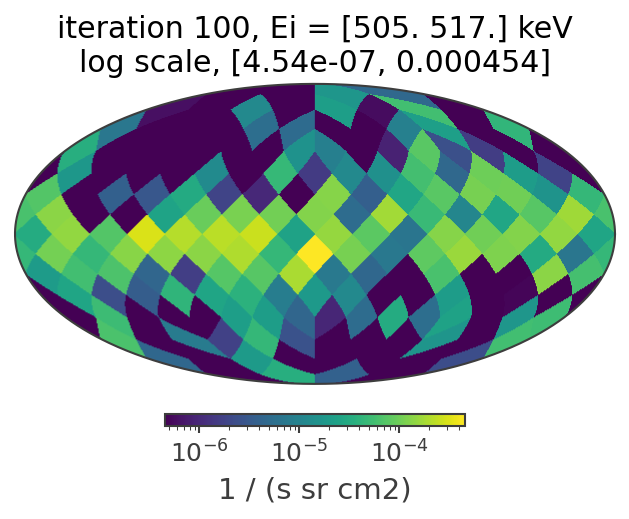

In [22]:
image = results[-1]["model"]
_column = image.contents[:, 0]
values = np.asarray(getattr(_column, "value", _column), dtype=float)

hi = float(values.max()) if VMAX is None else float(VMAX)
lo = hi / 1.0e3 if VMIN is None else float(VMIN)

# Log scale: these sources are extended, and on a linear scale the bulge
# saturates the colour bar and everything else reads as flat background.
#
# LogNorm has no representation for <= 0, and minimum_flux is 0.0 so empty pixels
# are expected.  Blank them rather than let them clip onto vmin, which would
# paint empty sky the same colour as the faintest real emission.
blank = int(np.count_nonzero(~(values > 0)))
values = np.where(values > 0, values, np.nan)

img, ax = HealpixMap(data=values, unit=image.unit).plot(
    "mollview", norm=LogNorm(vmin=lo, vmax=hi))
img.colorbar.set_label(str(image.unit))
plt.title(f"iteration {results[-1]['iteration']}, "
          f"Ei = {image.axes['Ei'].bounds[0]}\n"
          f"log scale, [{lo:.3g}, {hi:.3g}]")
plt.show()

if blank:
    print(f"{blank} of {values.size} pixels were <= 0 and are drawn blank")
